In [1]:
# --- Experiment parameters

# Name of experiment. Used for MLflow experiment name, output files, etc.
experiment_name = "NT-M4-Torch-DataLoader"

# Paths
root = '/Users/ntin/Documents/DermaML_local/hawkeye-hands-2024-07-29'

image_folder = '/images_processed/'
features_folder = '/features-2025-02-24/'
csv_file = '/metadata.csv'
segmentation_folder = '/segmentation_npys/'

# ------ Algorithm parameters

# train/test split
split = 0.7
epochs = 10
learning_rate = 1e3

In [2]:
# --- Imports

# Internal library
from dermaml.data import read_local_into_dict, read_local_into_lists
from dermaml.model_setup import read_segmentation_npy, square_resize

# Standard library
import os
import random 
import math
from datetime import datetime
# External packages
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
import pandas as pd
import torch
import torchvision


# Entropy
random.seed(42)
np.random.seed(42)

np.set_printoptions(precision=3, suppress=True)

Tutorial for dataloaders:  
[https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html#creating-a-custom-dataset-for-your-files]

In [56]:
from torchvision.io import decode_image
from torch.utils.data import Dataset
from torchvision import datasets

from PIL import Image

class HawkeyeHandsDataset(Dataset):
    def __init__(
            self, 
            metadata_file, 
            img_dir, 
            filename_jpeg, 
            label='age',
            metadata_filename_column = 'hand_image_file',
            transform=None, target_transform=None
            ):
        
        # load metadata
        self.metadata_all = pd.read_csv(metadata_file)
        self.metadata_filename_column = metadata_filename_column
        # filter metadata to only include images in dataset_filenames
        self.metadata = self.metadata_all[self.metadata_all[metadata_filename_column].isin(filename_jpeg)]
            
        # set labels
        self.classes = self.metadata[label]

        # load image files
        self.img_dir = img_dir
        self.filename_jpeg = filename_jpeg

        # set transformations
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.classes)

    def __getitem__(self, idx):
        fname = self.filename_jpeg[idx]
        img_path = os.path.join(self.img_dir, fname)
        image = Image.open(img_path)

        try:
            if fname in ['e372cfe9-dbf4-4308-86ca-fd17547d6b51.jpeg',
                        '748c093e-8c5f-4879-b4aa-8da5d954768f.jpeg',
                        '732c435e-5470-4aa0-b51c-5feffe76863f.jpeg',
                        '056ce0ab-bb2b-4792-aec7-956c754dc852.jpeg']:
                raise IndexError(f"Skipping corrupted image file: {fname}, {idx}")
            label = self.metadata.loc[self.metadata[self.metadata_filename_column] == fname, 'age'].values[0]
        except IndexError:
            raise IndexError(f"No label found for image file: {fname}, {idx}")
        
        if self.transform:
            image = self.transform(image)
        
        
        label = torch.tensor(float(label), dtype=torch.float32)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

In [57]:
annotations_file = root + '/metadata_processed.csv'
img_dir = root+image_folder

shuffled_im_files = os.listdir(root+image_folder)
random.shuffle(shuffled_im_files.copy())
# shuffled_im_files = [os.path.join(root+image_folder, f) for f in all_img_files]

splits = ['train', 'test']
image_count = len(shuffled_im_files)
train_size = math.floor(image_count * split)
train_files = shuffled_im_files[:train_size]
test_files = shuffled_im_files[train_size:]

print(len(train_files),)  # Expected: (403, 512, 512, 3) and (403, 1)
print(len(test_files))    # Expected: (N, 512, 512, 3) and (N, 1)

test_results = {}

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((128, 128)),
    torchvision.transforms.ToTensor()
])

image_datasets = {x: HawkeyeHandsDataset(
                        metadata_file=annotations_file, 
                        img_dir=img_dir, 
                        filename_jpeg=data,
                        label='age',
                        metadata_filename_column='hand_image_file',
                        transform=transform,
                    )
                  for x, data in zip(['train', 'val'], [train_files, test_files])
                  }


438
188


## Part 1: Setting up a basic CNN for Transfer Learning
https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html 

In [58]:
dataloaders = {x: torch.utils.data.DataLoader(
                        image_datasets[x], 
                        batch_size=4,
                        shuffle=True, 
                        num_workers=0,
                        )
              for x in ['train', 'val']
              }

In [59]:
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

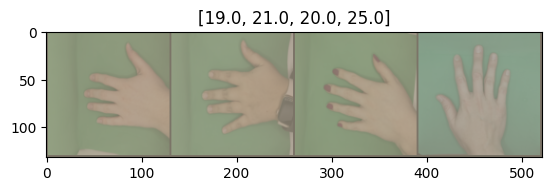

In [60]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))
class_names = image_datasets['train'].classes

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[float(x) for x in classes])

In [61]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [62]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [63]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features

# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 1)
criterion = nn.MSELoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [64]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------


/Users/ntin/DermaML/.venv/lib/python3.11/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([4])) that is different to the input size (torch.Size([4, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


IndexError: No label found for image file: 5473ca1a-4ecd-40f6-94b6-a5910f732592.jpeg, 83

In [53]:
df=image_datasets['val'].metadata

In [54]:
df[df['hand_image_file']=='5473ca1a-4ecd-40f6-94b6-a5910f732592.jpg']

,record_id,gender,gender_specify,birth_year,sex_assigned_at_birth,sex_assigned_at_birth_specify,race_ethnicity,race_ethnicity_specify,ethnicity,handedness,...,sunscreen_use,region,region_specify,hand_image_file,form_complete,age,reference_year,young_old_flag,gender_flag,hand


In [50]:
[x for x in df.hand_image_file.tolist() if '547' in x]

['e372cfe9-dbf4-4308-86ca-fd17547d6b51.jpeg',
 '748c093e-8c5f-4879-b4aa-8da5d954768f.jpeg',
 '732c435e-5470-4aa0-b51c-5feffe76863f.jpeg']

In [55]:
set(test_files) ^ set(df.hand_image_file.tolist())

{'056ce0ab-bb2b-4792-aec7-956c754dc852.jpeg'}

In [ ]:
['e372cfe9-dbf4-4308-86ca-fd17547d6b51.jpeg',
 '748c093e-8c5f-4879-b4aa-8da5d954768f.jpeg',
 '732c435e-5470-4aa0-b51c-5feffe76863f.jpeg',
'056ce0ab-bb2b-4792-aec7-956c754dc852.jpeg']